In [1]:
import os
os.getcwd()

from pathlib import Path
Path("build/pdd_dose.txt").exists()

True

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# SETTINGS YOU MUST CONFIRM
# -----------------------------
#BUILD_DIR = Path(".")  # <-- if you're already in build/ directory in Jupyter
BUILD_DIR = Path("build")     # <-- if notebook is in project root

NBIN_Z = 160
HALF_Z_MM = 40.0
DEPTH_MODE = "center"  # center is correct for voxel centers

# -----------------------------
# MEASURED PDD (FLASHdiamond)
# -----------------------------
meas_depth = np.array([
    1,2,3,4,5,6,7,8,9,10,
    11,12,13,14,15,16,17,18,19,20,
    21,22,23,24,25,26,27,28,29,30,
    31,33,35,37,39,41,43,45,47,49,
    51,56,61,66
], dtype=float)

meas_normC = np.array([
    94.62,94.39,96.64,96.86,97.31,98.65,97.76,98.88,99.10,99.10,
    98.65,99.10,99.10,100.00,98.65,99.33,98.43,98.21,97.31,97.53,
    96.19,96.19,94.39,94.39,92.60,91.03,90.36,87.89,85.87,83.18,
    80.27,74.22,66.82,58.97,51.57,40.81,32.06,23.54,15.92,9.64,
    5.38,1.12,1.12,1.12
], dtype=float)

meas_pdd = meas_normC / 100.0

# Avoid divide-by-zero in % differences
MEAS_EPS = 1e-6

# Optionally weight depths (e.g. emphasize fall-off region)
# Example: heavier weighting beyond 25 mm
def depth_weights(d):
    w = np.ones_like(d, dtype=float)
    w[d >= 25] = 2.0
    w[d >= 35] = 3.0
    return w

USE_WEIGHTS = True

# -----------------------------
# Helper: read Geant4 mesh dump
# -----------------------------
def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            try:
                ix = int(parts[0]); iy = int(parts[1]); iz = int(parts[2])
                val = float(parts[3])
                rows.append((ix, iy, iz, val))
            except ValueError:
                continue
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val"])

def sim_depth_axis(nbin_z, half_z_mm, mode="center"):
    full_len = 2.0 * half_z_mm
    dz = full_len / nbin_z
    if mode == "center":
        z = (np.arange(nbin_z) + 0.5) * dz
    else:
        z = np.arange(nbin_z) * dz
    return z, dz

# -----------------------------
# Parse params from filename
# Example: pdd_r001_E9p7_sE0p15_sTh0p0_N300000_J50014980_T1.txt
# -----------------------------
fname_re = re.compile(
    r"pdd_(?P<runid>r\d+)_E(?P<E>[\dp]+)_sE(?P<sE>[\dp]+)_sTh(?P<sTh>[\dp]+)_N(?P<N>\d+)_J(?P<J>\d+)_T(?P<T>\d+)\.txt$"
)

def p_to_float(s):
    # convert "9p7" -> 9.7
    return float(s.replace("p", "."))

def score_one_file(pdd_path: Path):
    m = fname_re.match(pdd_path.name)
    if not m:
        return None

    meta = m.groupdict()
    E = p_to_float(meta["E"])
    sE = p_to_float(meta["sE"])
    sTh = p_to_float(meta["sTh"])
    N = int(meta["N"])
    runid = meta["runid"]

    df = read_geant4_mesh_dump(pdd_path)
    g = df.groupby("iZ", as_index=False)["val"].sum()

    all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
    g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

    dose = g["val"].to_numpy()
    if dose.max() <= 0:
        return {
            "file": pdd_path.name, "runid": runid, "E": E, "sE": sE, "sTh": sTh, "N": N,
            "dz_mm": np.nan, "MAE": np.inf, "RMSE": np.inf, "MaxAbs": np.inf, "MeanAbs": np.inf
        }

    sim_depth, dz = sim_depth_axis(NBIN_Z, HALF_Z_MM, DEPTH_MODE)
    sim_pdd = dose / dose.max()

    # interpolate sim onto measured depths within sim range
    mask = (meas_depth >= sim_depth.min()) & (meas_depth <= sim_depth.max())
    md = meas_depth[mask]
    mp = meas_pdd[mask]
    sp = np.interp(md, sim_depth, sim_pdd)

    diff = sp - mp
    absdiff = np.abs(diff)

    if USE_WEIGHTS:
        w = depth_weights(md)
        w = w / w.sum()
        mae = np.sum(w * absdiff)
        rmse = np.sqrt(np.sum(w * diff**2))
    else:
        mae = absdiff.mean()
        rmse = np.sqrt((diff**2).mean())

    return {
        "file": pdd_path.name,
        "runid": runid,
        "E": E,
        "sE": sE,
        "sTh": sTh,
        "N": N,
        "dz_mm": dz,
        "MAE": mae,
        "RMSE": rmse,
        "MaxAbs": absdiff.max(),
        "MeanAbs": absdiff.mean(),
    }

# -----------------------------
# Run batch scoring
# -----------------------------
files = sorted(BUILD_DIR.glob("pdd_r*_E*_sE*_sTh*_N*_J*_T*.txt"))
print(f"Found {len(files)} PDD files")

rows = []
for f in files:
    r = score_one_file(f)
    if r is not None:
        rows.append(r)

results = pd.DataFrame(rows).sort_values(["MAE","RMSE","MaxAbs"]).reset_index(drop=True)

# Show best 10
display(results.head(10))
print("\nBest file:", results.loc[0, "file"])

Found 51 PDD files


,file,runid,E,sE,sTh,N,dz_mm,MAE,RMSE,MaxAbs,MeanAbs
0,pdd_r207_E9p925_sE1p05_sTh0p2_N500000_J5002606...,r207,9.925,1.05,0.2,500000,0.5,0.016943,0.023975,0.063689,0.013505
1,pdd_r208_E9p925_sE1p10_sTh0p2_N500000_J5002606...,r208,9.925,1.10,0.2,500000,0.5,0.017517,0.024625,0.067755,0.013773
2,pdd_r209_E9p925_sE1p15_sTh0p2_N500000_J5002606...,r209,9.925,1.15,0.2,500000,0.5,0.017655,0.024406,0.063446,0.013565
3,pdd_r206_E9p90_sE1p15_sTh0p2_N500000_J50026058...,r206,9.900,1.15,0.2,500000,0.5,0.018223,0.025679,0.069919,0.013995
4,pdd_r205_E9p90_sE1p10_sTh0p2_N500000_J50026057...,r205,9.900,1.10,0.2,500000,0.5,0.018958,0.026819,0.070149,0.014561
5,pdd_r204_E9p90_sE1p05_sTh0p2_N500000_J50026056...,r204,9.900,1.05,0.2,500000,0.5,0.019213,0.027687,0.071383,0.014718
6,pdd_r203_E9p875_sE1p15_sTh0p2_N500000_J5002605...,r203,9.875,1.15,0.2,500000,0.5,0.020101,0.028275,0.074065,0.015379
7,pdd_r704_E9p90_sE1p00_sTh0p2_N300000_J50021279...,r704,9.900,1.00,0.2,300000,0.5,0.020638,0.029553,0.075873,0.015537
8,pdd_r103_E9p85_sE1p20_sTh0p2_N500000_J50026038...,r103,9.850,1.20,0.2,500000,0.5,0.021147,0.029801,0.076648,0.016186
9,pdd_r202_E9p875_sE1p10_sTh0p2_N500000_J5002605...,r202,9.875,1.10,0.2,500000,0.5,0.021304,0.030107,0.077951,0.016237



Best file: pdd_r207_E9p925_sE1p05_sTh0p2_N500000_J50026060_T9.txt


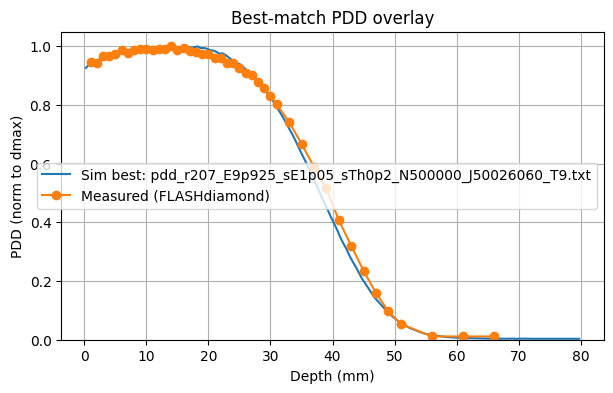

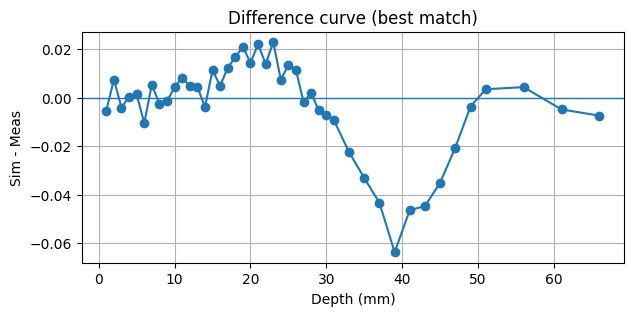

dz = 0.5
Best metrics: {'MAE': 0.016943338337905477, 'RMSE': 0.023974775160467098, 'MaxAbs': 0.06368850401901271, 'MeanAbs': 0.013505468800636076}


In [8]:
best_file = results.loc[0, "file"]
best_path = BUILD_DIR / best_file

df = read_geant4_mesh_dump(best_path)
g = df.groupby("iZ", as_index=False)["val"].sum()
all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

dose = g["val"].to_numpy()
sim_depth, dz = sim_depth_axis(NBIN_Z, HALF_Z_MM, DEPTH_MODE)
sim_pdd = dose / dose.max()

mask = (meas_depth >= sim_depth.min()) & (meas_depth <= sim_depth.max())
md = meas_depth[mask]
mp = meas_pdd[mask]
sp = np.interp(md, sim_depth, sim_pdd)

diff = sp - mp

plt.figure(figsize=(7,4))
plt.plot(sim_depth, sim_pdd, linewidth=1.5, label=f"Sim best: {best_file}")
plt.plot(meas_depth, meas_pdd, "o-", linewidth=1.5, label="Measured (FLASHdiamond)")
plt.xlabel("Depth (mm)")
plt.ylabel("PDD (norm to dmax)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.legend()
plt.title("Best-match PDD overlay")
plt.show()

plt.figure(figsize=(7,3))
plt.axhline(0, linewidth=1)
plt.plot(md, diff, "o-", linewidth=1.5)
plt.xlabel("Depth (mm)")
plt.ylabel("Sim - Meas")
plt.grid(True)
plt.title("Difference curve (best match)")
plt.show()

print("dz =", dz)
print("Best metrics:", results.loc[0, ["MAE","RMSE","MaxAbs","MeanAbs"]].to_dict())

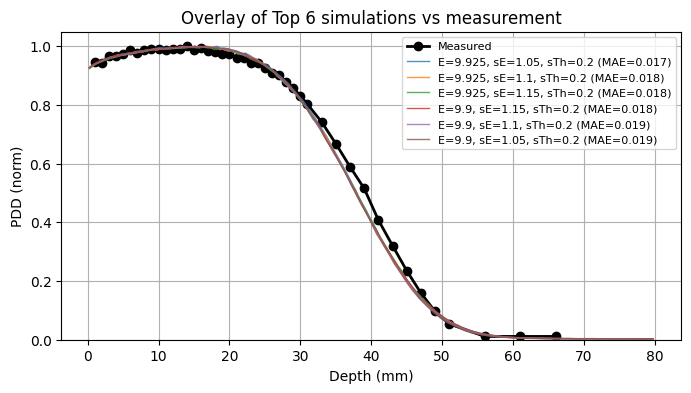

In [9]:
K = 6
top = results.head(K)

plt.figure(figsize=(8,4))
plt.plot(meas_depth, meas_pdd, "k-o", linewidth=2, label="Measured")

for _, row in top.iterrows():
    p = BUILD_DIR / row["file"]
    df = read_geant4_mesh_dump(p)
    g = df.groupby("iZ", as_index=False)["val"].sum()
    all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
    g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)
    dose = g["val"].to_numpy()
    if dose.max() <= 0:
        continue
    sim_depth, _ = sim_depth_axis(NBIN_Z, HALF_Z_MM, DEPTH_MODE)
    sim_pdd = dose / dose.max()
    plt.plot(sim_depth, sim_pdd, linewidth=1, alpha=0.8,
             label=f"E={row['E']}, sE={row['sE']}, sTh={row['sTh']} (MAE={row['MAE']:.3f})")

plt.xlabel("Depth (mm)")
plt.ylabel("PDD (norm)")
plt.grid(True)
plt.ylim(0, 1.05)
plt.title(f"Overlay of Top {K} simulations vs measurement")
plt.legend(fontsize=8)
plt.show()

In [10]:
sim_depth,_ = sim_depth_axis(NBIN_Z,HALF_Z_MM,DEPTH_MODE)
sim_pdd=dose/dose.max()
plt.plot(sim_depth,sim_pdd,linewidth=1,alpha=0.8

SyntaxError: incomplete input (1470746919.py, line 3)